# Modelos de Aprendizado de Máquina
## Random Forest e Gradient Boosting — Imóveis Grande Florianópolis

**Etapas:**
- 1. Preparação: variáveis do stepwise, split 80/20
- 2. Random Forest com RandomizedSearchCV
- 3. Gradient Boosting (XGBoost) com RandomizedSearchCV
- 4. Comparação dos modelos
- 5. SHAP values

**Referências:**
- Breiman (2001) — Random Forests
- Chen & Guestrin (2016) — XGBoost
- Grinsztajn et al. (2022) — tree-based models vs deep learning em dados tabulares

---
## Imports e configurações

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':        'Arial',
    'font.size':          10,
    'axes.labelsize':     11,
    'axes.labelcolor':    'black',
    'axes.titlesize':     0,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   True,
    'axes.spines.bottom': True,
    'axes.linewidth':     1.5,
    'axes.edgecolor':     'black',
    'xtick.color':        'black',
    'ytick.color':        'black',
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'axes.grid':          False,
    'axes.facecolor':     'white',
    'figure.facecolor':   'white',
    'figure.dpi':         120,
})

COR  = '#4878CF'
SEED = 42

def aplicar_estilo(ax):
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_linewidth(1.5)
        ax.spines[spine].set_color('black')
    ax.set_title('')
    ax.tick_params(colors='black')

print('OK')

OK


## Configurações de caminho e métricas

In [2]:
ENTRADA   = 'imoveis_sanitizado.csv'
SAIDA_DIR = 'ml_output'
os.makedirs(SAIDA_DIR, exist_ok=True)

def metricas(y_true_log, y_pred_log, label=''):
    y_true   = np.exp(y_true_log)
    y_pred   = np.exp(y_pred_log)
    rmse_rs  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_rs   = mean_absolute_error(y_true, y_pred)
    r2_rs    = r2_score(y_true, y_pred)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log   = r2_score(y_true_log, y_pred_log)
    mape     = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    if label:
        print(f'\n  {label}')
        print(f"  {'─'*45}")
        print(f'  R² (escala R$):  {r2_rs:.4f}')
        print(f'  R² (escala log): {r2_log:.4f}')
        print(f'  RMSE (R$):       R$ {rmse_rs:,.0f}')
        print(f'  MAE  (R$):       R$ {mae_rs:,.0f}')
        print(f'  MAPE:            {mape:.2f}%')
    return {
        'R2_reais':   round(r2_rs, 4),
        'R2_log':     round(r2_log, 4),
        'RMSE_reais': round(rmse_rs, 0),
        'MAE_reais':  round(mae_rs, 0),
        'MAPE':       round(mape, 2),
        'RMSE_log':   round(rmse_log, 4),
    }

print(f'Saída em: {os.path.abspath(SAIDA_DIR)}')

Saída em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\ml_output


---
## Etapa 1 — Preparação dos dados

In [3]:
df = pd.read_csv(ENTRADA, encoding='utf-8-sig', low_memory=False)

NUMERICAS  = ['tamanho_m2', 'quartos', 'banheiros', 'vagas', 'valor']
AMENIDADES = ['piscina', 'sacada', 'churrasqueira',
              'elevador', 'academia', 'salao_de_festas']
# imovel_mobiliado excluído — removido pelo stepwise (p=0,054)

df[NUMERICAS]  = df[NUMERICAS].apply(pd.to_numeric, errors='coerce')
df[AMENIDADES] = df[AMENIDADES].fillna(0).astype(int)
df             = df[NUMERICAS + AMENIDADES + ['regiao', 'tipo']].dropna()

df['log_valor']      = np.log(df['valor'])
df['log_tamanho_m2'] = np.log(df['tamanho_m2'])

print(f'Observações: {len(df):,}')

Observações: 8,056


In [4]:
df_model = pd.get_dummies(df, columns=['regiao', 'tipo'], drop_first=True)
subs = str.maketrans('ãõçéêáâóôúí', 'aoceeaaooui')
df_model.columns = [
    c.translate(subs).replace(' ', '_')
     .replace('[', '').replace(']', '')
     .replace('(', '').replace(')', '')
    for c in df_model.columns
]
for col in df_model.columns:
    if df_model[col].dtype == bool:
        df_model[col] = df_model[col].astype('int8')

DUMMIES  = [c for c in df_model.columns
            if c.startswith('regiao_') or c.startswith('tipo_')]
FEATURES = ['log_tamanho_m2', 'quartos', 'banheiros', 'vagas'] + AMENIDADES + DUMMIES
TARGET   = 'log_valor'

X = df_model[FEATURES].astype('float64')
y = df_model[TARGET].astype('float64')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Features ({len(FEATURES)})')
print(f'Treino: {len(X_train):,}  |  Teste: {len(X_test):,}')

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

Features (18)
Treino: 6,444  |  Teste: 1,612


---
## Etapa 2 — Random Forest
⏳ Pode levar alguns minutos.

In [5]:
param_grid_rf = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=40, cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1, verbose=1,
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print('\nMelhores hiperparâmetros:')
for k, v in sorted(rf_search.best_params_.items()):
    print(f'  {k:<22} {v}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores hiperparâmetros:
  max_depth              30
  max_features           0.5
  min_samples_leaf       2
  min_samples_split      5
  n_estimators           300


In [6]:
met_rf_treino = metricas(y_train, rf_best.predict(X_train), 'Treino — Random Forest')
met_rf_teste  = metricas(y_test,  rf_best.predict(X_test),  'Teste  — Random Forest')


  Treino — Random Forest
  ─────────────────────────────────────────────
  R² (escala R$):  0.7754
  R² (escala log): 0.9160
  RMSE (R$):       R$ 942,314
  MAE  (R$):       R$ 324,204
  MAPE:            16.89%

  Teste  — Random Forest
  ─────────────────────────────────────────────
  R² (escala R$):  0.7339
  R² (escala log): 0.8186
  RMSE (R$):       R$ 941,302
  MAE  (R$):       R$ 457,138
  MAPE:            25.69%


---
## Etapa 3 — XGBoost
⏳ Pode levar alguns minutos.

In [7]:
param_grid_xgb = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma':            [0, 0.1, 0.3],
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=SEED, n_jobs=-1,
                 tree_method='hist', verbosity=0),
    param_distributions=param_grid_xgb,
    n_iter=40, cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=SEED, n_jobs=-1, verbose=1,
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

print('\nMelhores hiperparâmetros:')
for k, v in sorted(xgb_search.best_params_.items()):
    print(f'  {k:<22} {v}')

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Melhores hiperparâmetros:
  colsample_bytree       0.8
  gamma                  0.1
  learning_rate          0.05
  max_depth              6
  min_child_weight       1
  n_estimators           200
  subsample              0.6


In [8]:
met_xgb_treino = metricas(y_train, xgb_best.predict(X_train), 'Treino — XGBoost')
met_xgb_teste  = metricas(y_test,  xgb_best.predict(X_test),  'Teste  — XGBoost')


  Treino — XGBoost
  ─────────────────────────────────────────────
  R² (escala R$):  0.8042
  R² (escala log): 0.8717
  RMSE (R$):       R$ 879,817
  MAE  (R$):       R$ 381,431
  MAPE:            21.86%

  Teste  — XGBoost
  ─────────────────────────────────────────────
  R² (escala R$):  0.7419
  R² (escala log): 0.8183
  RMSE (R$):       R$ 927,113
  MAE  (R$):       R$ 462,804
  MAPE:            26.27%


---
## Etapa 4 — Comparação dos modelos

In [9]:
ols_sk         = LinearRegression().fit(X_train, y_train)
met_ols_treino = metricas(y_train, ols_sk.predict(X_train))
met_ols_teste  = metricas(y_test,  ols_sk.predict(X_test))

tabela = pd.DataFrame({
    'Modelo':          ['OLS (baseline)', 'Random Forest', 'XGBoost'],
    'R² Teste':        [met_ols_teste['R2_reais'],   met_rf_teste['R2_reais'],   met_xgb_teste['R2_reais']],
    'RMSE Teste (R$)': [met_ols_teste['RMSE_reais'], met_rf_teste['RMSE_reais'], met_xgb_teste['RMSE_reais']],
    'MAE Teste (R$)':  [met_ols_teste['MAE_reais'],  met_rf_teste['MAE_reais'],  met_xgb_teste['MAE_reais']],
    'MAPE Teste (%)':  [met_ols_teste['MAPE'],       met_rf_teste['MAPE'],       met_xgb_teste['MAPE']],
    'R² Treino':       [met_ols_treino['R2_reais'],  met_rf_treino['R2_reais'],  met_xgb_treino['R2_reais']],
})

tabela.to_csv(os.path.join(SAIDA_DIR, 'comparacao_modelos.csv'),
              index=False, encoding='utf-8-sig')

print('Checagem de overfitting (R² treino - R² teste):')
for _, row in tabela.iterrows():
    diff = row['R² Treino'] - row['R² Teste']
    flag = ' ⚠ possível overfitting' if diff > 0.05 else ' ✓'
    print(f"  {row['Modelo']:<20} Δ={diff:.4f}{flag}")

tabela

Checagem de overfitting (R² treino - R² teste):
  OLS (baseline)       Δ=-0.1354 ✓
  Random Forest        Δ=0.0415 ✓
  XGBoost              Δ=0.0623 ⚠ possível overfitting


,Modelo,R² Teste,RMSE Teste (R$),MAE Teste (R$),MAPE Teste (%),R² Treino
0,OLS (baseline),0.7168,971153.0,504628.0,29.17,0.5814
1,Random Forest,0.7339,941302.0,457138.0,25.69,0.7754
2,XGBoost,0.7419,927113.0,462804.0,26.27,0.8042


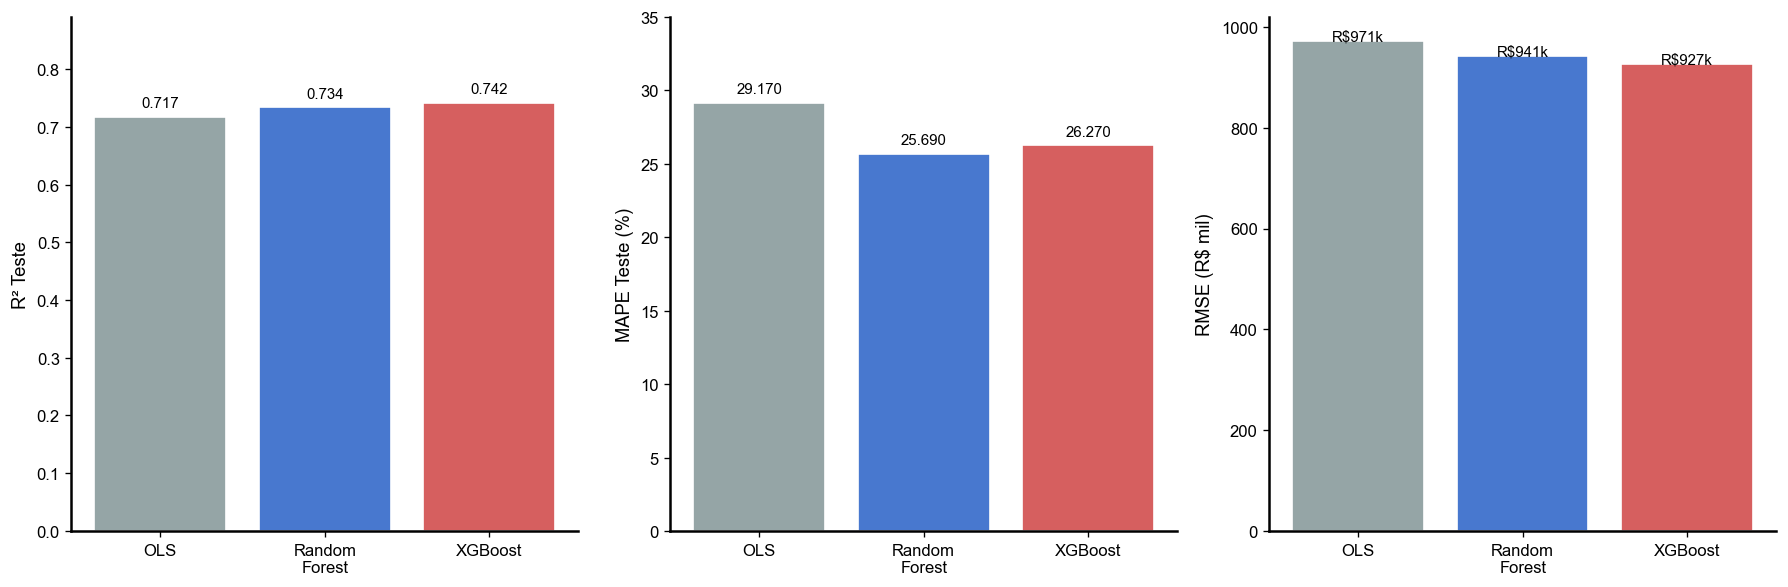

In [10]:
# Gráfico comparativo — R², MAPE e RMSE
modelos_labels = ['OLS', 'Random\nForest', 'XGBoost']
cores_modelos  = ['#95a5a6', COR, '#D65F5F']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes[:2], ['R² Teste', 'MAPE Teste (%)']):
    bars = ax.bar(modelos_labels, tabela[col], color=cores_modelos, edgecolor='white')
    ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9)
    ax.set_ylim(0, tabela[col].max() * 1.2)
    ax.set_ylabel(col)
    aplicar_estilo(ax)

rmse_k = tabela['RMSE Teste (R$)'] / 1000
bars = axes[2].bar(modelos_labels, rmse_k, color=cores_modelos, edgecolor='white')
for i, v in enumerate(rmse_k):
    axes[2].text(i, v + 1, f'R${v:.0f}k', ha='center', fontsize=9)
axes[2].set_ylabel('RMSE (R$ mil)')
aplicar_estilo(axes[2])

plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'comparacao_modelos.png'), bbox_inches='tight', dpi=150)
plt.show()

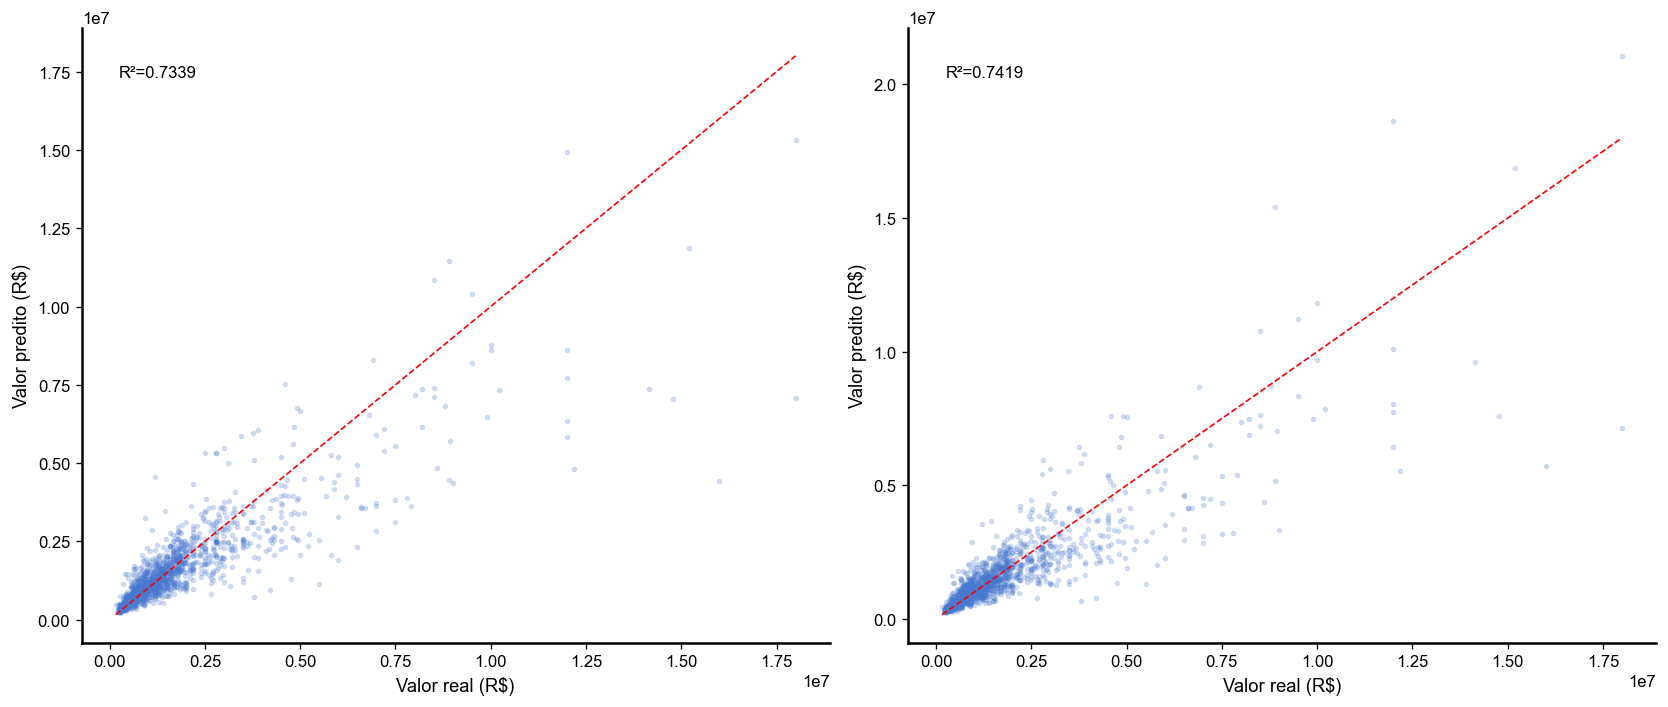

In [11]:
# Real vs Predito — RF e XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
y_real = np.exp(y_test)

for ax, (nome, modelo) in zip(axes, [('Random Forest', rf_best), ('XGBoost', xgb_best)]):
    y_pred = np.exp(modelo.predict(X_test))
    ax.scatter(y_real, y_pred, alpha=0.2, s=6, color=COR)
    lim = [y_real.min(), y_real.max()]
    ax.plot(lim, lim, 'r--', linewidth=1)
    r2 = r2_score(y_real, y_pred)
    ax.set_xlabel('Valor real (R$)')
    ax.set_ylabel('Valor predito (R$)')
    ax.annotate(f'R²={r2:.4f}', xy=(0.05, 0.92),
                xycoords='axes fraction', fontsize=10)
    aplicar_estilo(ax)

plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'real_vs_predito.png'), bbox_inches='tight', dpi=150)
plt.show()

---
## Etapa 5 — SHAP values
⏳ Pode levar 1-2 minutos.

In [12]:
melhor_nome   = 'XGBoost' if met_xgb_teste['R2_reais'] >= met_rf_teste['R2_reais'] else 'Random Forest'
melhor_modelo = xgb_best  if melhor_nome == 'XGBoost' else rf_best
print(f'Modelo selecionado para SHAP: {melhor_nome}')

X_shap = (X_test
          .sample(min(1000, len(X_test)), random_state=SEED)
          .astype('float64'))

print('Calculando SHAP values...')
explainer   = shap.TreeExplainer(melhor_modelo)
shap_values = explainer(X_shap)
print('Concluído.')

Modelo selecionado para SHAP: XGBoost
Calculando SHAP values...
Concluído.


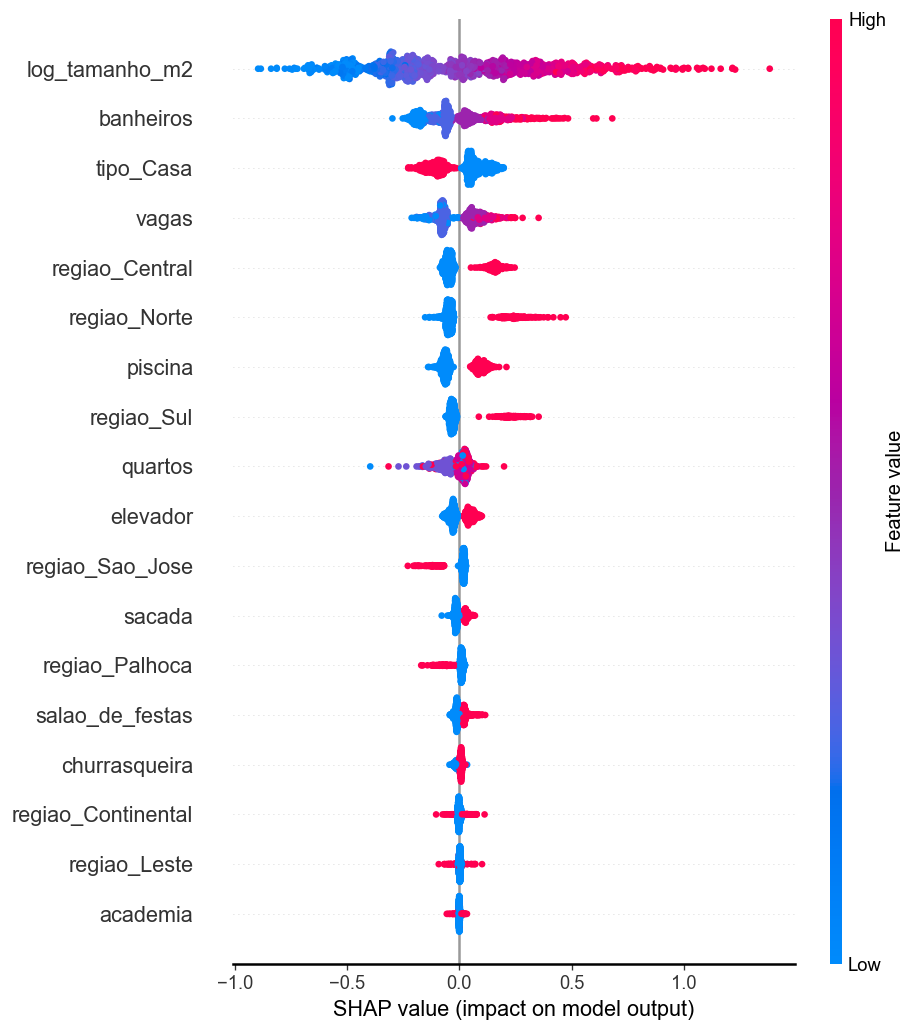

In [13]:
# Beeswarm — impacto e direção
# Nota: gráficos SHAP têm estilo próprio — título removido manualmente
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=18, show=False)
plt.gcf().axes[0].set_title('')
plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'shap_beeswarm.png'), bbox_inches='tight', dpi=150)
plt.show()

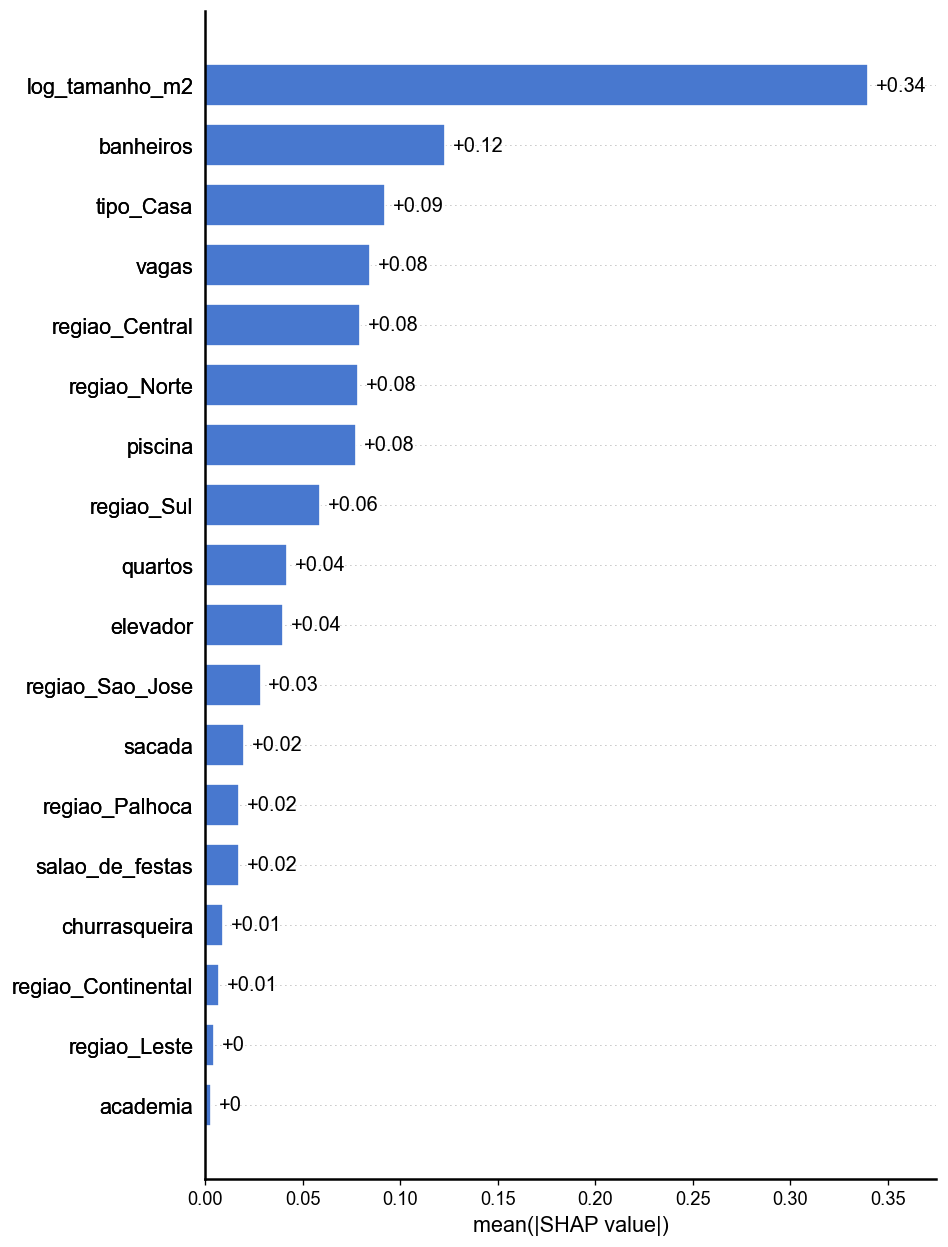

In [18]:
# Bar plot — importância média absoluta
plt.figure(figsize=(9, 7))
shap.plots.bar(shap_values, max_display=18, show=False)

ax = plt.gcf().axes[0]
for bar in ax.patches:
    bar.set_facecolor(COR)
    bar.set_edgecolor('white')

ax.set_title('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1.5)
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['bottom'].set_color('black')
ax.tick_params(colors='black')
for obj in plt.gcf().findobj(plt.Text):
    obj.set_color('black')

plt.tight_layout()
plt.savefig(os.path.join(SAIDA_DIR, 'shap_importancia.png'), bbox_inches='tight', dpi=150)
plt.show()

In [15]:
# Tabela de importâncias SHAP
importancias = np.abs(shap_values.values).mean(axis=0)
shap_df = pd.DataFrame({
    'feature':           FEATURES,
    'shap_mean_abs':     importancias,
    'shap_mean_abs_pct': 100 * importancias / importancias.sum(),
}).sort_values('shap_mean_abs', ascending=False).round(4)

shap_df.to_csv(os.path.join(SAIDA_DIR, 'shap_importancias.csv'),
               index=False, encoding='utf-8-sig')
print('Top 10 por importância SHAP:')
shap_df.head(10)

Top 10 por importância SHAP:


,feature,shap_mean_abs,shap_mean_abs_pct
0,log_tamanho_m2,0.3400,30.273199
2,banheiros,0.1232,10.969900
17,tipo_Casa,0.0924,8.230700
3,vagas,0.0844,7.519100
10,regiao_Central,0.0794,7.069700
13,regiao_Norte,0.0784,6.982100
4,piscina,0.0773,6.883200
15,regiao_Sul,0.0589,5.248000
1,quartos,0.0422,3.761600
7,elevador,0.0398,3.544100


---
## Relatório final

In [19]:
print('CONCLUÍDO')
print(f"\n  {'Modelo':<20} {'R² Teste':>10} {'RMSE (R$)':>14} {'MAPE':>8}")
print(f"  {'─'*55}")
for _, row in tabela.iterrows():
    print(f"  {row['Modelo']:<20} {row['R² Teste']:>10.4f} "
          f"R${row['RMSE Teste (R$)']:>11,.0f} {row['MAPE Teste (%)']:>7.2f}%")
print(f'\nMelhor modelo: {melhor_nome}')
print(f'\nArquivos em: {os.path.abspath(SAIDA_DIR)}')
for arq in sorted(os.listdir(SAIDA_DIR)):
    print(f'  {arq}')

CONCLUÍDO

  Modelo                 R² Teste      RMSE (R$)     MAPE
  ───────────────────────────────────────────────────────
  OLS (baseline)           0.7168 R$    971,153   29.17%
  Random Forest            0.7339 R$    941,302   25.69%
  XGBoost                  0.7419 R$    927,113   26.27%

Melhor modelo: XGBoost

Arquivos em: c:\Users\gabri\Desktop\scraping_imoveis\ARQUIVOS PARA GITHUB\ml_output
  comparacao_modelos.csv
  comparacao_modelos.png
  real_vs_predito.png
  shap_beeswarm.png
  shap_importancia.png
  shap_importancias.csv
